In [1]:
# imports 
import numpy as np 
import pandas as pd 
import pingouin as pg
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
import glob
import os
import h5_utilities_module as h5u
from tqdm import tqdm as tqdm
import statsmodels.api as sm
from scipy import stats
from statsmodels.tsa.arima.model import ARIMA
warnings.filterwarnings('ignore')
warnings.filterwarnings("ignore", message="Mean of empty slice", category=RuntimeWarning)

In [2]:
#functions
def calculate_mean_and_interval(data, type='sem', num_samples=1000, alpha=0.05):
    """
    Calculate mean and either SEM or bootstrapped CI for each column of the input array, disregarding NaN values.

    Parameters:
    - data: 2D numpy array
    - type: str, either 'sem' or 'bootstrap_ci'
    - num_samples: int, number of bootstrap samples (applicable only for type='bootstrap_ci')
    - alpha: float, significance level for the confidence interval (applicable only for type='bootstrap_ci')

    Returns:
    - means: 1D numpy array containing means for each column
    - interval: 1D numpy array containing SEMs or bootstrapped CIs for each column
    """
    nan_mask = ~np.isnan(data)
    
    nanmean_result = np.nanmean(data, axis=0)
    n_valid_values = np.sum(nan_mask, axis=0)
    
    if type == 'sem':
        nanstd_result = np.nanstd(data, axis=0)
        interval = nanstd_result / np.sqrt(n_valid_values)
        
    elif type == 'percentile':
        interval = np.mean(np.array([np.abs(nanmean_result - np.nanpercentile (data, 5, axis=0)), np.abs(nanmean_result - np.nanpercentile (data, 95, axis=0))]))
        
        
    elif type == 'bootstrap':
        n_rows, n_cols = data.shape

        # Initialize array to store bootstrap means
        bootstrap_means = np.zeros((num_samples, n_cols))

        # Perform bootstrap resampling for each column
        for col in range(n_cols):
            
            if np.sum(nan_mask[:, col]) > 0:
                bootstrap_samples = np.random.choice(data[:, col][nan_mask[:, col]], size=(num_samples, n_rows), replace=True)
                bootstrap_means[:, col] = np.nanmean(bootstrap_samples, axis=1)
            else:
                bootstrap_means[:, col] = np.nan

        # Calculate confidence interval bounds
        ci_lower = np.percentile(bootstrap_means, 100 * (alpha / 2), axis=0)
        ci_upper = np.percentile(bootstrap_means, 100 * (1 - alpha / 2), axis=0)
        
        interval = np.nanmean([abs(bootstrap_means - ci_lower), abs(bootstrap_means - ci_upper)], axis=0)
        
        interval = np.nanmean(interval, axis=0)

    else:
        raise ValueError("Invalid 'type' argument. Use either 'sem' or 'bootstrap'.")
    
    return nanmean_result, interval


def get_ch_and_unch_vals(bhv):
    """
    Extracts chosen (ch_val) and unchosen (unch_val) values associated with each trial.

    Parameters:
    - bhv (DataFrame): DataFrame behavioral data.

    Returns:
    - ch_val (ndarray): Array of chosen values for each trial.
    - unch_val (ndarray): Array of unchosen values for each trial. 
                          - places 0s for unchosen values on forced choice trials
    """
    ch_val = np.zeros(shape=(len(bhv, )))
    unch_val = np.zeros(shape=(len(bhv, )))

    bhv['r_val'] = bhv['r_val'].fillna(0)
    bhv['l_val'] = bhv['l_val'].fillna(0)

    ch_left = bhv['side'] == -1
    ch_right = bhv['side'] == 1

    ch_val[ch_left] = bhv['l_val'].loc[ch_left].astype(int)
    ch_val[ch_right] = bhv['r_val'].loc[ch_right].astype(int)

    unch_val[ch_left] = bhv['r_val'].loc[ch_left].astype(int)
    unch_val[ch_right] = bhv['l_val'].loc[ch_right].astype(int)

    return ch_val, unch_val


def arima_preprocess_trials(in_data, arima_params=(10, 2, 2)):
   """
   Apply ARIMA preprocessing to all trials of a time series.
   
   Parameters:
   -----------
   in_data: array [n_trials x n_times] - time series data
   arima_params: tuple - (p, d, q) ARIMA order
   
   Returns:
   --------
   whitened_data: array [n_trials x n_times] - ARIMA residuals or original data
   success_mask: array [n_trials] - boolean mask indicating ARIMA success per trial
   """
   
   n_trials, n_times = in_data.shape
   whitened_data = np.full((n_trials, n_times), np.nan)
   success_mask = np.zeros(n_trials, dtype=bool)
   
   for t in tqdm(range(n_trials)):
       try:
           model = ARIMA(in_data[t, :], order=arima_params)
           fitted = model.fit()
           whitened_data[t, :] = fitted.resid
           success_mask[t] = True
           
       except Exception:
           # Use original data if ARIMA fails
           whitened_data[t, :] = in_data[t, :]
           success_mask[t] = False
   
   return whitened_data, success_mask



def transmission_analysis(data_A, data_B, lags, time_step, win_size):
    """
    Perform sliding window transmission analysis between two neural time series.

    Tests directional predictive relationships by applying lagged regression analysis
    within sliding temporal windows. Based on the approach described in Crowe et al. 
    (2013) Nature Neuroscience for detecting information transmission between brain areas.

    Parameters
    ----------
    data_A : ndarray, shape (n_trials, n_times)
        Neural data from brain area A (e.g., posterior probabilities from decoding).
        Should be preprocessed (e.g., ARIMA whitened) to remove autocorrelation.
    data_B : ndarray, shape (n_trials, n_times)  
        Neural data from brain area B, same format as data_A.
    lags : array_like
        Lag values to test (in time bins). Should start from 0.
        e.g., np.arange(0, 9) tests lags 0-8 bins.
    time_step : float
        Time duration of each bin in milliseconds (e.g., 25.0 for 25ms bins).
    win_size : float  
        Sliding window size in milliseconds (e.g., 500.0 for 500ms windows).
        
    Returns
    -------
    a2b_f : ndarray, shape (n_lags, n_time_steps)
        F-statistics testing whether area A predicts area B at each lag and time step.
        Higher values indicate stronger predictive relationships.
    b2a_f : ndarray, shape (n_lags, n_time_steps)
        F-statistics testing whether area B predicts area A at each lag and time step.
    bin_centers : ndarray, shape (n_time_steps,)
        Indices of original time bins corresponding to the center of each sliding window.
        Maps columns in a2b_f/b2a_f back to original data time points. 
    """

    n_samples = int(win_size / time_step)  # Convert to integer
    n_trials, n_times = data_A.shape
    n_time_steps = n_times - n_samples + 1  # Number of valid window positions
    
    # Initialize result arrays [n_lags x n_times]
    a2b_f = np.full((len(lags), n_time_steps), np.nan)
    b2a_f = np.full((len(lags), n_time_steps), np.nan)
    
    # Calculate bin centers for each window position
    bin_centers = np.arange(n_time_steps) + n_samples // 2
    
    # Loop over valid window positions
    for t_ix, window_start in enumerate(range(n_time_steps)):
        window_end = window_start + n_samples
       
        # Extract windows from all trials
        a_window = data_A[:, window_start:window_end]  # [trials x window_bins]
        b_window = data_B[:, window_start:window_end]  # [trials x window_bins]
       
        for lag_ix, this_lag in enumerate(lags):
           
            # Test A -> B
            if this_lag > 0:
                a_pred = a_window[:, :-this_lag].flatten()  # Earlier A values
                b_targ = b_window[:, this_lag:].flatten()   # Later B values
            else:
                a_pred = a_window.flatten()
                b_targ = b_window.flatten()
               
            # Test B -> A 
            if this_lag > 0:
                b_pred = b_window[:, :-this_lag].flatten()  # Earlier B values
                a_targ = a_window[:, this_lag:].flatten()   # Later A values
            else:
                b_pred = b_window.flatten()
                a_targ = a_window.flatten()
           
            # Run regressions and compute F-statistics
            if len(a_pred) > 10:  # Minimum data check
                try:
                    X = sm.add_constant(a_pred)
                    model = sm.OLS(b_targ, X).fit()
                    a2b_f[lag_ix, t_ix] = model.fvalue
                except:
                    pass
                   
            if len(b_pred) > 10:
                try:
                    X = sm.add_constant(b_pred)  
                    model = sm.OLS(a_targ, X).fit()
                    b2a_f[lag_ix, t_ix] = model.fvalue
                except:
                    pass
               
    return a2b_f, b2a_f, bin_centers

In [3]:
# where are the data?
data_dir = 'C:/Users/thome/Documents/PYTHON/OFC-CdN 3 state self control/decoder_output/'

# get their relevant paths
data_files = h5u.find_h5_files(data_dir)

In [4]:
# initialize lists to accumulate data into
OFC_ch = []
OFC_unch = []
OFC_alt_ch = []
OFC_alt_unch = []
CdN_ch = []
CdN_unch = []
CdN_alt_ch = []
CdN_alt_unch = []
bhv = pd.DataFrame()
OFC_acc = []
CdN_acc = []
subject = []
session = []
OFC_cue_pp = []


# accumulate data from each file

for f_num, this_file in enumerate(data_files):
    
    if 'D' in Path(this_file).stem:
        s = 0
    else:
        s = 1
            
    # Append the data to the lists
    subject.append(np.ones(len(h5u.pull_from_h5(this_file, 'OFC_acc_mean')), )*s)
    session.append(np.ones(len(h5u.pull_from_h5(this_file, 'OFC_acc_mean')), )*f_num)

    bhv = pd.concat([bhv, pd.read_hdf(this_file, key='bhv')], ignore_index=True)
    
    OFC_ch.append(h5u.pull_from_h5(this_file, 'OFC_ch'))
    OFC_unch.append(h5u.pull_from_h5(this_file, 'OFC_unch'))
    OFC_alt_ch.append(h5u.pull_from_h5(this_file, 'OFC_alt_ch'))
    OFC_alt_unch.append(h5u.pull_from_h5(this_file, 'OFC_alt_unch'))
    
    CdN_ch.append(h5u.pull_from_h5(this_file, 'CdN_ch'))
    CdN_unch.append(h5u.pull_from_h5(this_file, 'CdN_unch'))
    CdN_alt_ch.append(h5u.pull_from_h5(this_file, 'CdN_alt_ch'))
    CdN_alt_unch.append(h5u.pull_from_h5(this_file, 'CdN_alt_unch'))
    
    OFC_acc.append(h5u.pull_from_h5(this_file, 'OFC_acc_mean'))
    CdN_acc.append(h5u.pull_from_h5(this_file, 'CdN_acc_mean'))
    
    ts = h5u.pull_from_h5(this_file, 'ts')
    
    
# convert everything back to arrays
subject = np.concatenate(subject, axis=0)
session = np.concatenate(session, axis=0)

OFC_ch = np.concatenate(OFC_ch, axis=0)
OFC_unch = np.concatenate(OFC_unch, axis=0)
OFC_alt_ch = np.concatenate(OFC_alt_ch, axis=0)
OFC_alt_unch = np.concatenate(OFC_alt_unch, axis=0)

CdN_ch = np.concatenate(CdN_ch, axis=0)
CdN_unch = np.concatenate(CdN_unch, axis=0)
CdN_alt_ch = np.concatenate(CdN_alt_ch, axis=0)
CdN_alt_unch = np.concatenate(CdN_alt_unch, axis=0)

OFC_acc = np.concatenate(OFC_acc, axis=0)
CdN_acc = np.concatenate(CdN_acc, axis=0)

In [ ]:
# create indices for the single and double saccade trials
single_ix = bhv['n_sacc'] == 1
double_ix = bhv['n_sacc'] == 2

# create indices for each subject
d_ix = subject == 0
k_ix = subject == 1

In [10]:
# whiten the OFC and CDN data
d_ofc_whitened, d_ofc_success = arima_preprocess_trials(OFC_ch[single_ix & d_ix, :], (10, 2, 2))
d_cdn_whitened, d_cdn_success = arima_preprocess_trials(CdN_ch[single_ix & d_ix, :], (10, 2, 2))

k_ofc_whitened, k_ofc_success = arima_preprocess_trials(OFC_ch[single_ix & k_ix, :], (10, 2, 2))
k_cdn_whitened, k_cdn_success = arima_preprocess_trials(CdN_ch[single_ix & k_ix, :], (10, 2, 2))

100%|██████████| 3592/3592 [17:57<00:00,  3.34it/s]


In [11]:
# run the transmission analysis detailed in Crowe et al. 
lags = np.arange(0, 9)
time_step = 25  # milliseconds between samples
win_size = 500  # milliseconds  
d_ofc2cdn_f, d_cdn2ofc_f, bin_indices = transmission_analysis(d_ofc_whitened, d_cdn_whitened, lags, time_step, win_size)
k_ofc2cdn_f, k_cdn2ofc_f, _ = transmission_analysis(k_ofc_whitened, k_cdn_whitened, lags, time_step, win_size)

In [12]:
# now we need to bootstrap the difference of f stats
d_fstat_diff = d_ofc2cdn_f - d_cdn2ofc_f
k_fstat_diff = k_ofc2cdn_f - k_cdn2ofc_f

n_boots = 1000

# Bootstrap by shuffling trial pairing
d_boot_diffs = []
k_boot_diffs = []

for i in tqdm(range(n_boots)):
    # Shuffle trials to break simultaneity
    d_shuffled_idx = np.random.permutation(len(d_ofc_whitened))
    d_ofc_shuffled = d_ofc_whitened[d_shuffled_idx, :]

    k_shuffled_idx = np.random.permutation(len(k_ofc_whitened))
    k_ofc_shuffled = k_ofc_whitened[k_shuffled_idx, :]
    
    # Run transmission analysis on shuffled data
    d_ofc2cdn_null, d_cdn2ofc_null, _ = transmission_analysis(d_ofc_shuffled, d_cdn_whitened, lags, time_step, win_size)
    d_boot_diffs.append(d_ofc2cdn_null - d_cdn2ofc_null)

    k_ofc2cdn_null, k_cdn2ofc_null, _ = transmission_analysis(k_ofc_shuffled, k_cdn_whitened, lags, time_step, win_size)
    k_boot_diffs.append(k_ofc2cdn_null - k_cdn2ofc_null)

# Compare real difference to null distribution
d_boot_diffs = np.array(d_boot_diffs)
k_boot_diffs = np.array(k_boot_diffs)


100%|██████████| 1000/1000 [2:41:49<00:00,  9.71s/it] 


In [ ]:
# mask out insignificant differences - visualize only significant effects

upper_bound = 99
lower_bound = 1

d_fstat_cis = np.percentile(d_boot_diffs, [lower_bound, upper_bound], axis=0)
d_sig_fstat_diffs = np.zeros_like(d_ofc2cdn_f)
d_fstat_diffs = d_ofc2cdn_f - d_cdn2ofc_f

k_fstat_cis = np.percentile(k_boot_diffs, [lower_bound, upper_bound], axis=0)
k_sig_fstat_diffs = np.zeros_like(k_ofc2cdn_f)
k_fstat_diffs = k_ofc2cdn_f - k_cdn2ofc_f

for this_lag in range(len(lags)):

    d_under_ci_ix = d_fstat_diffs[this_lag,:] < d_fstat_cis[0,this_lag,:]
    d_over_ci_ix = d_fstat_diffs[this_lag,:] > d_fstat_cis[1,this_lag,:]

    d_sig_fstat_diffs[this_lag, d_under_ci_ix | d_over_ci_ix] = d_fstat_diffs[this_lag, d_under_ci_ix | d_over_ci_ix]

    k_under_ci_ix = k_fstat_diffs[this_lag,:] < k_fstat_cis[0,this_lag,:]
    k_over_ci_ix = k_fstat_diffs[this_lag,:] > k_fstat_cis[1,this_lag,:]

    k_sig_fstat_diffs[this_lag, k_under_ci_ix | k_over_ci_ix] = k_fstat_diffs[this_lag, k_under_ci_ix | k_over_ci_ix]

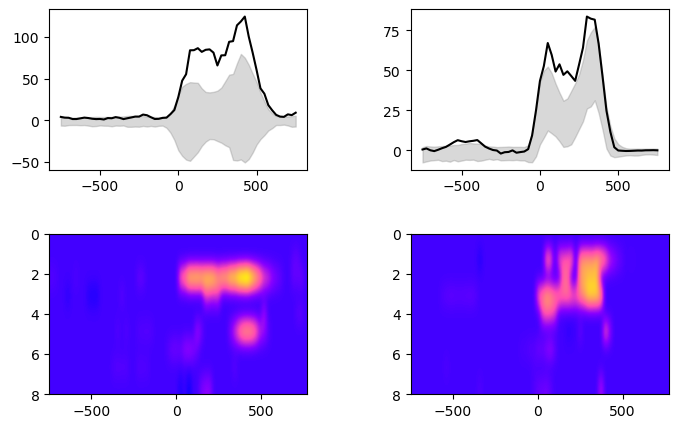

In [53]:
# now let's plot
window_ts = ts[bin_indices]
fig, ax = plt.subplots(2, 2, figsize=(8, 5))
plt.subplots_adjust(wspace=0.4, hspace=0.4)  # add some white space

ax[0,0].fill_between(window_ts, d_fstat_cis[0,2,:], d_fstat_cis[1,2,:], color='tab:gray', alpha = .3)
ax[0,0].plot(window_ts, d_fstat_diffs[2,:], color='black')

# First imshow plot with extent argument
im1 = ax[1,0].imshow(d_sig_fstat_diffs, cmap='gnuplot2', aspect='auto', vmin = -50, vmax = 100, 
                     interpolation='bicubic', extent=[window_ts[0], window_ts[-1], lags[-1], lags[0]])

ax[0,1].fill_between(window_ts, k_fstat_cis[0,3,:], k_fstat_cis[1,3,:], color='tab:gray', alpha = .3)
ax[0,1].plot(window_ts, k_fstat_diffs[3,:], color='black')

# Second imshow plot with extent argument
im2 = ax[1,1].imshow(k_sig_fstat_diffs, cmap='gnuplot2', aspect='auto', vmin = -50, vmax = 100, 
                     interpolation='bicubic', extent=[window_ts[0], window_ts[-1], lags[-1], lags[0]])